In [1]:
import numpy as np
from tqdm import tqdm
import spiceypy as spy
from Utils import *
from utils_jacobian import *
import matplotlib.pyplot as plt

In [2]:
#utils conversions and constants
mu = CanonicalUnits().mu
print(f"mu in Canonical units: {mu} AU^3/year^2")

mu in Canonical units: 39.48894168123623 AU^3/year^2


Conteo de objetos dentro de caja 

In [3]:
#load state vector
N = int(1e7)

#elements_uniform = compute_uniform_elements(N)
#state_vector_uniform = compute_state_vector(elements_uniform, mu)

file = 'state_vector_uniform_N1e7_1.txt'
state_vector_uniform = np.loadtxt(file)

In [4]:
#volumen de la caja

#centro de la caja
centro_x = 1; centro_y = 0; centro_z = 0
centro_vx = 0; centro_vy = (mu/1)**0.5; centro_vz = 0
center = [centro_x, centro_y, centro_z, centro_vx, centro_vy, centro_vz]

#tamaño de la caja
dr = 0.05
dx = dr; dy = dr; dz = dr
dv = (5000 * (1/CanonicalUnits.AU_m) * CanonicalUnits.year)
dvx = dv; dvy = dv; dvz = dv
size = [dx, dy, dz, dvx, dvy, dvz]

idx_value = 0
n, selected_object = count_particles_in_volume(state_vector_uniform, center, size, idx_value)
print(f'Number of objects inside volume: {n}')

print('state vector seleccionado para calcular el Jacobiano: ', selected_object)

Number of objects inside volume: 55
state vector seleccionado para calcular el Jacobiano:  [ 0.95318348  0.03504397 -0.01161599  0.05194033  6.80212447  0.69605412]


Calculo teorico

In [5]:
dX=np.array([1e-3]*6)
args=dict(mu=mu)
E_num, JEoX_num = computeNumericalJacobian(X2E,selected_object,dX,**args)
E_num, JEoX_num

#distribucion elements uniform 

q_max = 1.3; q_min = 0
e_max = 1; e_min = 0
i_max = np.pi; i_min = 0
Omega_max = 2*np.pi; Omega_min = 0
w_max = 2*np.pi; w_min = 0
E_max = 2*np.pi; E_min = 0

bounds = [(q_min, q_max), (e_min, e_max), (i_min, i_max),
          (Omega_min, Omega_max), (w_min, w_max), (E_min, E_max)]

PE = uniform_pdf(bounds)

det = np.linalg.det(JEoX_num)
print('determinante del Jacobiano numerico: ', det)

Delta = compute_phase_space_volume(size)
n_numerical = compute_theoretical_count(N, PE, det, Delta)
print('numero de objetos teorico: ', n_numerical)

determinante del Jacobiano numerico:  0.47323505409808375
numero de objetos teorico:  43.849151841747485


### Variar tamaño de la caja

In [ ]:
N = int(1e7)

centro_x = 1; centro_y = 0; centro_z = 0
centro_vx = 0; centro_vy = (mu/1)**0.5; centro_vz = 0
center = [centro_x, centro_y, centro_z, centro_vx, centro_vy, centro_vz]

#variemos unicamente el tamaño en r de la caja
drs = np.linspace(0.05, 0.5, 10)
dv = (5000 * (1/CanonicalUnits.AU_m) * CanonicalUnits.year)
dvx = dv; dvy = dv; dvz = dv

idx_value = 4
dX=np.array([1e-3]*6)
args=dict(mu=mu)

n_size = []
N_size = []
state_vector_uniform = None if state_vector_uniform is None else state_vector_uniform
print(type(state_vector_uniform))
for deltas in tqdm(drs):
    dr = deltas
    dx = dr; dy = dr; dz = dr
    size = [dx, dy, dz, dvx, dvy, dvz]

    n, selected_object = count_particles_in_volume(state_vector_uniform, center, size, idx_value)
    n_size.append(n)

    dX=np.array([1e-3]*6)
    args=dict(mu=mu)
    E_num, JEoX_num = computeNumericalJacobian(X2E,selected_object,dX,**args)
    det = np.linalg.det(JEoX_num)

    Delta = compute_phase_space_volume(size)
    n_numerical = compute_theoretical_count(N, PE, det, Delta)

    N_size.append(n_numerical)

<class 'numpy.ndarray'>


100%|██████████| 10/10 [00:06<00:00,  1.61it/s]


In [23]:
#variemos unicamente el tamaño en v de la caja
dr = 0.1
dx = dr; dy = dr; dz = dr

dvs = np.linspace((1000 * (1/CanonicalUnits.AU_m) * CanonicalUnits.year), (5000 * (1/CanonicalUnits.AU_m) * CanonicalUnits.year), 10)

idx_value = 4
dX=np.array([1e-3]*6)
args=dict(mu=mu)

n_sizev = []
N_sizev = []
state_vector_uniform = None if state_vector_uniform is None else state_vector_uniform
print(type(state_vector_uniform))
for deltasv in tqdm(dvs):
    dv = deltasv
    dvx = dv; dvy = dv; dvz = dv
    size = [dx, dy, dz, dvx, dvy, dvz]

    n, selected_object = count_particles_in_volume(state_vector_uniform, center, size, idx_value)
    n_sizev.append(n)

    dX=np.array([1e-3]*6)
    args=dict(mu=mu)
    E_num, JEoX_num = computeNumericalJacobian(X2E,selected_object,dX,**args)
    det = np.linalg.det(JEoX_num)

    Delta = compute_phase_space_volume(size)
    n_numerical = compute_theoretical_count(N, PE, det, Delta)

    N_sizev.append(n_numerical)

<class 'numpy.ndarray'>


100%|██████████| 10/10 [00:05<00:00,  1.74it/s]


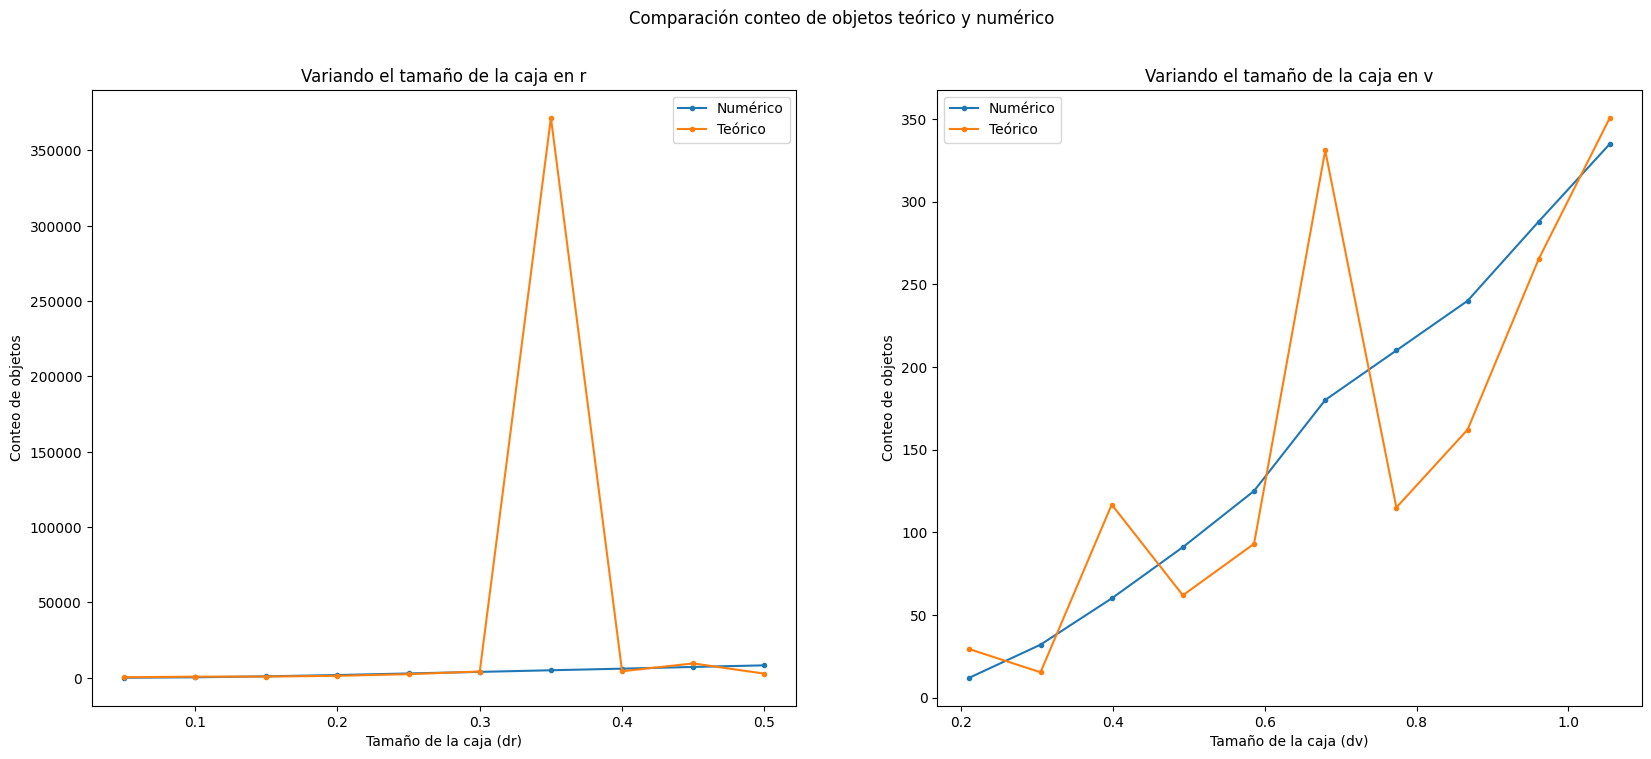

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(20,8))
axs[0].plot(drs, n_size, '.-', label='Numérico')
axs[0].plot(drs, N_size, '.-', label='Teórico')
axs[0].set_title('Variando el tamaño de la caja en r')
axs[0].set_xlabel('Tamaño de la caja (dr)')
axs[0].set_ylabel('Conteo de objetos')
axs[0].legend()

axs[1].plot(dvs, n_sizev, '.-', label='Numérico')
axs[1].plot(dvs, N_sizev, '.-', label='Teórico')
axs[1].set_xlabel('Tamaño de la caja (dv)')
axs[1].set_ylabel('Conteo de objetos')
axs[1].set_title('Variando el tamaño de la caja en v')
axs[1].legend()      

plt.suptitle("Comparación conteo de objetos teórico y numérico")
plt.show();

### Variar centro de la caja

In [ ]:
#variemos unicamente el centro en r de la caja

N = int(1e7)

centro_r = np.linspace(0, 0.5, 10)
centro_vx = 0; centro_vy = (mu/1)**0.5; centro_vz = 0

#tamaño de la caja
dr = 0.1
dx = dr; dy = dr; dz = dr
dv = (5000 * (1/CanonicalUnits.AU_m) * CanonicalUnits.year)
dvx = dv; dvy = dv; dvz = dv
size = [dx, dy, dz, dvx, dvy, dvz]

idx_value = 0
dX=np.array([1e-3]*6)
args=dict(mu=mu)

n_centro = []
N_centro = []
state_vector_uniform = None if state_vector_uniform is None else state_vector_uniform
print(type(state_vector_uniform))
for cr in tqdm(centro_r):
    centro_x = cr; centro_y = cr; centro_z = cr
    center = [centro_x, centro_y, centro_z, centro_vx, centro_vy, centro_vz]

    n, selected_object = count_particles_in_volume(state_vector_uniform, center, size, idx_value)
    n_centro.append(n)

    dX=np.array([1e-3]*6)
    args=dict(mu=mu)
    E_num, JEoX_num = computeNumericalJacobian(X2E,selected_object,dX,**args)
    det = np.linalg.det(JEoX_num)

    Delta = compute_phase_space_volume(size)
    n_numerical = compute_theoretical_count(N, PE, det, Delta)

    N_centro.append(n_numerical)

<class 'numpy.ndarray'>


100%|██████████| 10/10 [00:05<00:00,  1.82it/s]


In [30]:
#variemos unicamente el centro en v de la caja
N = int(1e7)

centro_v = np.linspace(0, 0.5, 10)
centro_x = 1; centro_y = 0; centro_z = 0

#tamaño de la caja
dr = 0.1
dx = dr; dy = dr; dz = dr
dv = (5000 * (1/CanonicalUnits.AU_m) * CanonicalUnits.year)
dvx = dv; dvy = dv; dvz = dv
size = [dx, dy, dz, dvx, dvy, dvz]

idx_value = 0
dX=np.array([1e-3]*6)
args=dict(mu=mu)

n_centrov = []
N_centrov = []
state_vector_uniform = None if state_vector_uniform is None else state_vector_uniform
print(type(state_vector_uniform))
for cv in tqdm(centro_v):
    centro_vx = cv; centro_vy = (mu/1)**0.5; centro_vz = cv
    center = [centro_x, centro_y, centro_z, centro_vx, centro_vy, centro_vz]

    n, selected_object = count_particles_in_volume(state_vector_uniform, center, size, idx_value)
    n_centrov.append(n)

    dX=np.array([1e-3]*6)
    args=dict(mu=mu)
    E_num, JEoX_num = computeNumericalJacobian(X2E,selected_object,dX,**args)
    det = np.linalg.det(JEoX_num)

    Delta = compute_phase_space_volume(size)
    n_numerical = compute_theoretical_count(N, PE, det, Delta)

    N_centrov.append(n_numerical)

<class 'numpy.ndarray'>


100%|██████████| 10/10 [00:05<00:00,  1.89it/s]


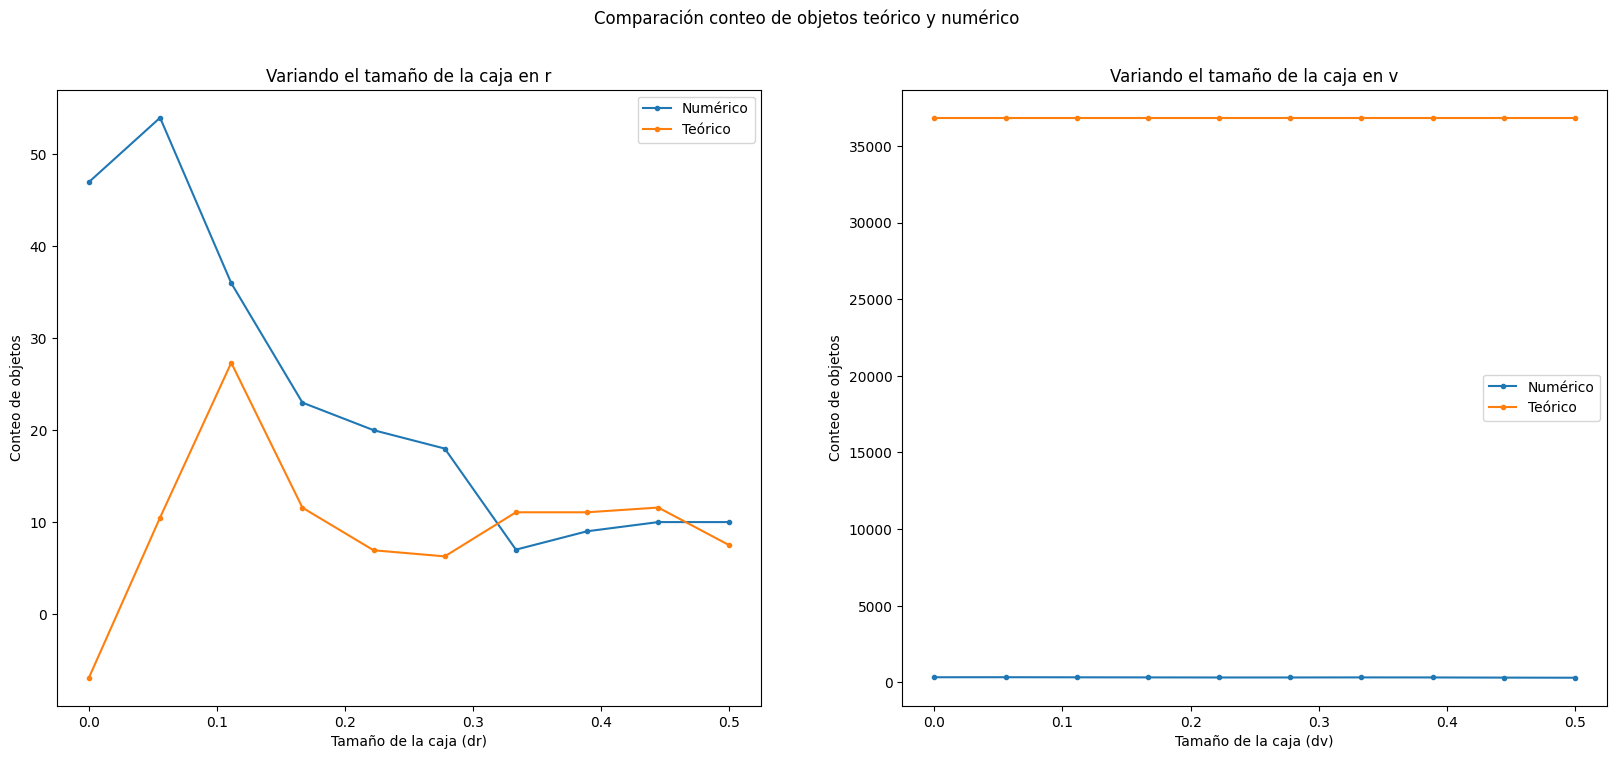

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(20,8))
axs[0].plot(centro_r, n_centro, '.-', label='Numérico')
axs[0].plot(centro_r, N_centro, '.-', label='Teórico')
axs[0].set_title('Variando el tamaño de la caja en r')
axs[0].set_xlabel('Tamaño de la caja (dr)')
axs[0].set_ylabel('Conteo de objetos')
axs[0].legend()

axs[1].plot(centro_v, n_centrov, '.-', label='Numérico')
axs[1].plot(centro_v, N_centrov, '.-', label='Teórico')
axs[1].set_xlabel('Tamaño de la caja (dv)')
axs[1].set_ylabel('Conteo de objetos')
axs[1].set_title('Variando el tamaño de la caja en v')
axs[1].legend()      

plt.suptitle("Comparación conteo de objetos teórico y numérico")
plt.show();